# Legendre basis approximations by activation

For each degree $p=0,\ldots,p_{\max}$, the three columns compare the ReLU, tanh, and RePU-2 emulators of

$$\psi_p(x)=\sqrt{2p+1}\,P_p(x), \qquad d\rho(x)=\frac{dx}{2},$$

against the exact three-term-recurrence evaluation.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch

from neural_polynomial_emulation import (
    emulated_legendre_basis,
    exact_legendre_basis,
)

PMAX = 20
NUM_POINTS = 1201
RELU_LAYERS = 12
TANH_TOLERANCE = 1e-4

if PMAX < 0:
    raise ValueError("PMAX must be nonnegative")


## Basis evaluation

Each emulator returns all columns from degree zero through `PMAX`. The tanh construction uses automatic tolerance- and dtype-dependent step selection.


In [2]:
x = torch.linspace(-1.0, 1.0, NUM_POINTS, dtype=torch.float64)
exact = exact_legendre_basis(x, PMAX).numpy()

approximations = {
    "ReLU": emulated_legendre_basis(
        x, PMAX, product="relu", num_layers=RELU_LAYERS
    ).numpy(),
    "tanh": emulated_legendre_basis(
        x, PMAX, product="tanh", tanh_tolerance=TANH_TOLERANCE
    ).numpy(),
    "RePU-2": emulated_legendre_basis(
        x, PMAX, product="repu2"
    ).numpy(),
}
x_numpy = x.numpy()


## Approximations

Rows index the polynomial degree and columns index the multiplication activation. Each panel reports the grid maximum error.


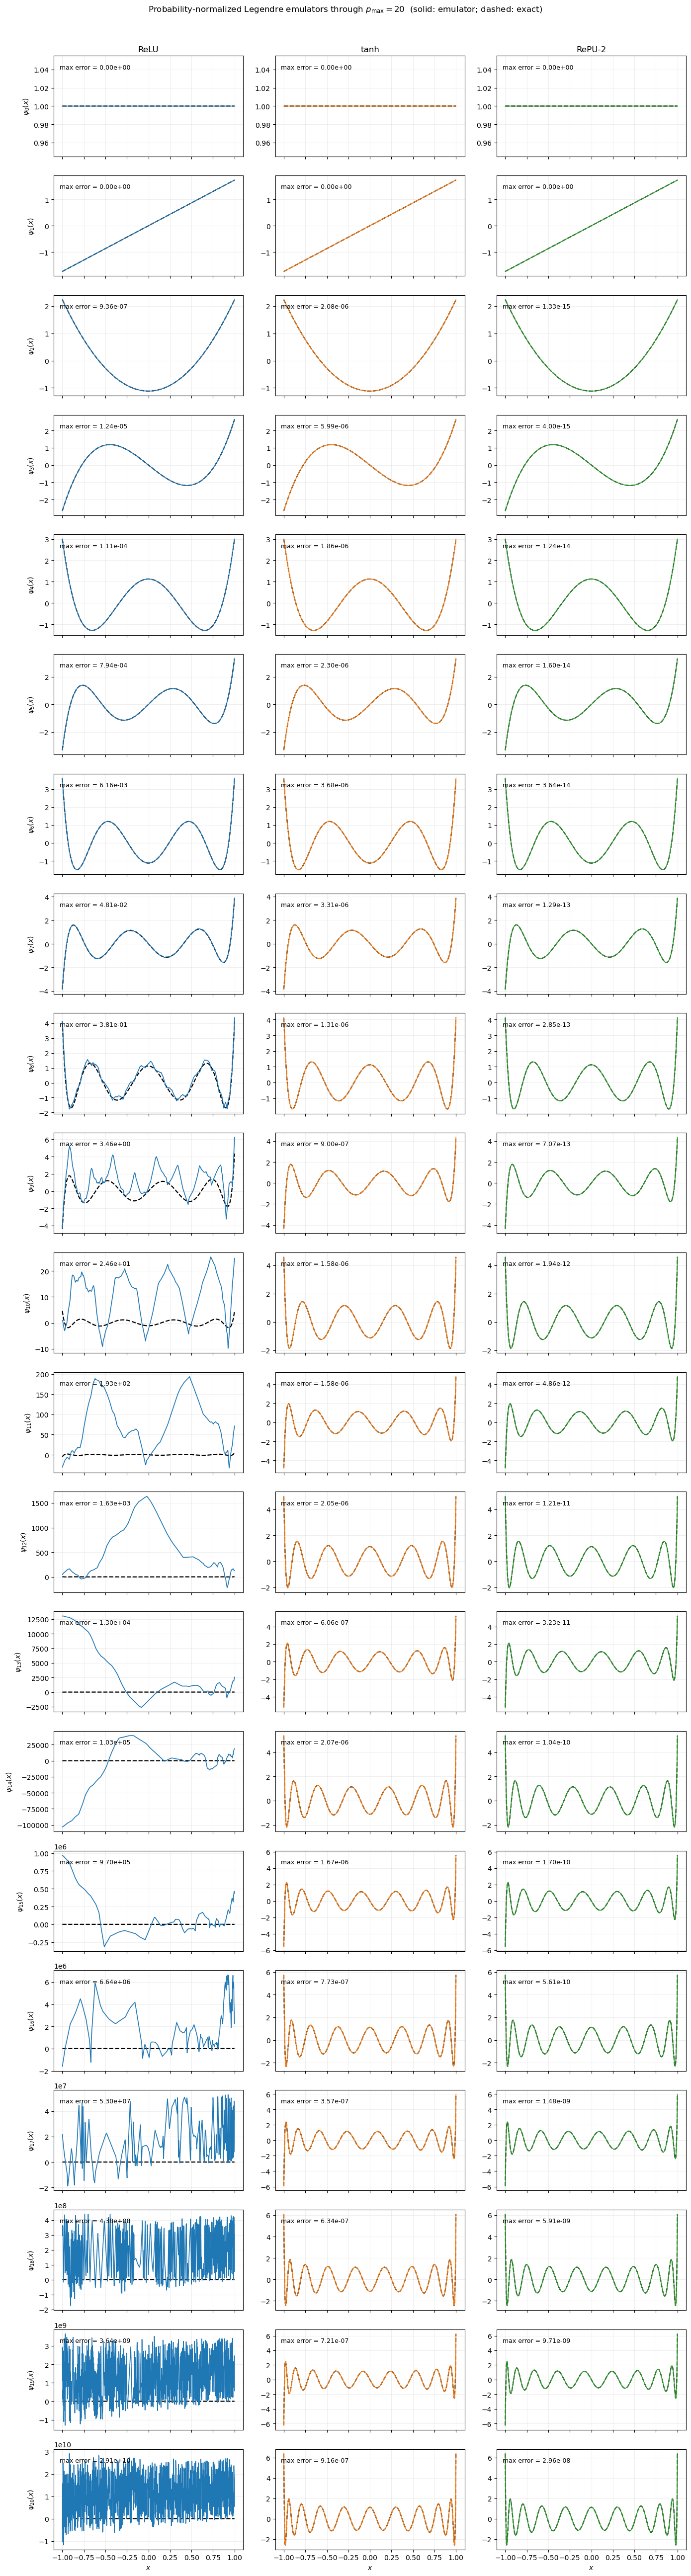

In [3]:
colors = {"ReLU": "tab:blue", "tanh": "tab:orange", "RePU-2": "tab:green"}
row_height = 2.45
header_height = 0.38
figure_height = row_height * (PMAX + 1) + header_height
fig, axes = plt.subplots(
    PMAX + 1,
    len(approximations),
    figsize=(14, figure_height),
    sharex=True,
    squeeze=False,
)

for degree in range(PMAX + 1):
    for column, (name, approximate) in enumerate(approximations.items()):
        ax = axes[degree, column]
        ax.plot(x_numpy, exact[:, degree], color="black", linestyle="--", linewidth=1.6, label="exact")
        ax.plot(x_numpy, approximate[:, degree], color=colors[name], linewidth=1.2, label=name)
        error = np.max(np.abs(approximate[:, degree] - exact[:, degree]))
        ax.text(0.03, 0.92, f"max error = {error:.2e}", transform=ax.transAxes, va="top", fontsize=9)
        ax.grid(alpha=0.2)
        if degree == 0:
            ax.set_title(name)
        if column == 0:
            ax.set_ylabel(rf"$\psi_{{{degree}}}(x)$")
        if degree == PMAX:
            ax.set_xlabel(r"$x$")

fig.suptitle(
    rf"Probability-normalized Legendre emulators through $p_{{\max}}={PMAX}$"
    "  (solid: emulator; dashed: exact)",
    x=0.5,
    y=1.0 - 0.04 / figure_height,
    ha="center",
    va="top",
)
fig.tight_layout(rect=(0, 0, 1, 1.0 - header_height / figure_height))
plt.show()
